In [22]:
import pandas as pd
import matplotlib.pyplot as plt

clean_india_fires = pd.read_csv("C:/Users/nekos/geo876-final-project/geo876-final-project/data/processed/clean_india_fires.csv")

clean_india_fires.head()

,latitude,longitude,frp,daynight,datetime
0,17.90913,82.63764,4.76,D,2026-05-14 07:12:00
1,17.90961,82.63640,4.82,D,2026-05-14 07:12:00
2,18.20374,77.79069,12.03,D,2026-05-14 07:12:00
3,18.20650,77.79298,8.55,D,2026-05-14 07:12:00
4,18.47787,79.45326,7.81,D,2026-05-14 07:12:00


In [23]:
# Ensure datetime column is in datetime format
clean_india_fires["datetime"] = pd.to_datetime(clean_india_fires["datetime"])

In [24]:
# Create required columns
clean_india_fires["Day"] = clean_india_fires["datetime"].dt.date
clean_india_fires["Time"] = clean_india_fires["datetime"].dt.strftime("%H:%M")

# Convert day/night labels
clean_india_fires["Day or Night"] = clean_india_fires["daynight"].map({"D": "Day", "N": "Night"})

# Combine latitude and longitude into a coordinates column
clean_india_fires["Coordinates"] = (
    clean_india_fires["latitude"].round(2).astype(str) + ", " +
    clean_india_fires["longitude"].round(2).astype(str)
)
clean_india_fires.head()

,latitude,longitude,frp,daynight,datetime,Day,Time,Day or Night,Coordinates
0,17.90913,82.63764,4.76,D,2026-05-14 07:12:00,2026-05-14,07:12,Day,"17.91, 82.64"
1,17.90961,82.63640,4.82,D,2026-05-14 07:12:00,2026-05-14,07:12,Day,"17.91, 82.64"
2,18.20374,77.79069,12.03,D,2026-05-14 07:12:00,2026-05-14,07:12,Day,"18.2, 77.79"
3,18.20650,77.79298,8.55,D,2026-05-14 07:12:00,2026-05-14,07:12,Day,"18.21, 77.79"
4,18.47787,79.45326,7.81,D,2026-05-14 07:12:00,2026-05-14,07:12,Day,"18.48, 79.45"


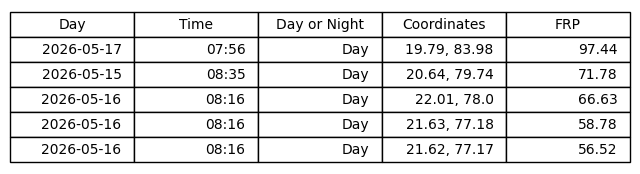

In [29]:
# Select the top 5 fires with the highest FRP across all days
top5_fires = (
    clean_india_fires
    .nlargest(5, "frp")[["Day", "Time", "Day or Night", "Coordinates", "frp"]]
    .rename(columns={"frp": "FRP"})
)

save_path = f"C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_top5_fires.png"

fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')

# Create table
table = ax.table(
    cellText=top5_fires.values,
    colLabels=top5_fires.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1,1.5)

# Save the figure
plt.savefig(save_path, bbox_inches='tight', dpi=300)

# Show table
plt.show()

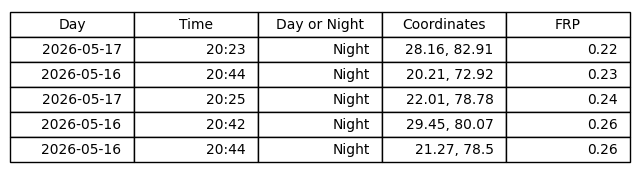

In [26]:
# Select the top 5 fires with the smallest FRP across all days
bottom5_fires = (
    clean_india_fires
    .nsmallest(5, "frp")[["Day", "Time", "Day or Night", "Coordinates", "frp"]]
    .rename(columns={"frp": "FRP"})
)

save_path = f"C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_bottom5_fires.png"

fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')

# Create table
table = ax.table(
    cellText=bottom5_fires.values,
    colLabels=bottom5_fires.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1,1.5)

# Save the figure
plt.savefig(save_path, bbox_inches='tight', dpi=300)

# Show table
plt.show()